In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pickle, pandas as pd, zipfile, xml.etree.ElementTree as ET
from pathlib import Path
from scipy.ndimage import maximum_filter


In [37]:
from pathlib import Path
# Path to repo root — change if running from a different location
BASE_DIR = Path("/Users/elipieri/repos/SeamStress")

# ── Panel titles ─────────────────────────────────────────────────────────────
TITLES = {
    "ethylene":     "Ethylene",
    "butadiene_s0": "Butadiene $S_0/S_1$",
    "butadiene_s1": "Butadiene $S_1/S_2$",
    "benzene_s0":   "Benzene $S_0/S_1$",
    "benzene_s1":   "Benzene $S_1/S_2$",
}

# ── Order of panels (top-left to bottom-right, left to right) ────────────────
DATASET_ORDER = ["ethylene", "butadiene_s0", "butadiene_s1", "benzene_s0", "benzene_s1"]

# ── Per-dataset peak-finding parameters ──────────────────────────────────────
DATASET_PARAMS = {
    "ethylene":     dict(min_peak_dist=10, peak_threshold=0.005),
    "butadiene_s0": dict(min_peak_dist=5, peak_threshold=0.1),
    "butadiene_s1": dict(min_peak_dist=5, peak_threshold=0.01),
    "benzene_s0":   dict(min_peak_dist=5, peak_threshold=0.005),
    "benzene_s1":   dict(min_peak_dist=5, peak_threshold=0.005),
}

# ── Custom MECI display labels (None = use raw name) ─────────────────────────
# Example: {"HH_Dissociation": "HH", "CC_Dissociation": "CC"}
MECI_LABELS = {
    "ethylene":     {},
    "butadiene_s0": {},
    "butadiene_s1": {},
    "benzene_s0":   {},
    "benzene_s1":   {},
}
MECI_ANNOTATE = False   # set False to hide all MECI labels

# ── Manual axis limits (None = auto-zoom to MECI range) ──────────────────────
# Set as [xmin, xmax, ymin, ymax] or None for auto
MANUAL_LIMITS = {
    "ethylene":     [-7, 21,-5,16],
    "butadiene_s0": [-4, 12,2,13.5],
    "butadiene_s1": [24, 36,6,14],
    "benzene_s0":   [-12, 15,1,13],
    "benzene_s1":   [0, 15,-8,5],
}
PAD_FRAC = 0.20   # fractional padding around MECI range (used when limits are auto)

# ── Appearance ───────────────────────────────────────────────────────────────
DENSITY_CMAP  = "rocket"   # colormap for spawn density
SCATTER_S     = 6
SCATTER_ALPHA = 1.0
MECI_S        = 120
MECI_S_MIN    = 20    # minimum star size (least-populated MECI)
BASIN_S       = 150
LABEL_SIZE    = 11
TICK_SIZE     = 9
ANNOT_SIZE    = 6

# ── Figure size and output ────────────────────────────────────────────────────
FIG_W      = 4.5   # width per panel (inches)
FIG_H      = 4.5   # height per panel (inches)
OUTPUT_DPI = 300
OUTPUT_FILE = str(BASE_DIR / "seam_basin" / "combined_scatter_dm1_dm2.png")
OUTPUT_FILE_2 = str(BASE_DIR / "seam_basin" / "combined_scatter_dm1_dm2.svg")


In [38]:
def load_dataset(name):
    out = BASE_DIR / "seam_basin" / name
    emb_spawn = np.load(out / "spawn_embedding_3d.npy")
    emb_meci  = np.load(out / "meci_embedding_3d.npy")
    kde_caches = sorted(out.glob("kde_cache_bw*.pkl"))
    with open(kde_caches[0], "rb") as f:
        cache = pickle.load(f)
    spawn_density = cache["spawn_density"]
    grid_caches = sorted(out.glob("kde_grid_cache_bw*_n200.npy"))
    axes_caches = sorted(out.glob("kde_grid_axes_bw*_n200.pkl"))
    zz3d = np.load(grid_caches[0])
    with open(axes_caches[0], "rb") as f:
        axes_1d = pickle.load(f)
    metrics    = pd.read_csv(out / "meci_metrics_grid_3d.csv")
    meci_names = metrics["meci"].tolist()
    return emb_spawn, emb_meci, spawn_density, zz3d, axes_1d, meci_names


def find_modes(zz3d, axes_1d, min_peak_dist, peak_threshold):
    fp        = np.ones([min_peak_dist * 2 + 1] * 3)
    local_max = (maximum_filter(zz3d, footprint=fp) == zz3d)
    local_max &= zz3d >= peak_threshold * zz3d.max()
    peak_idx  = np.argwhere(local_max)
    return np.array([[axes_1d[d][idx[d]] for d in range(3)] for idx in peak_idx])



def _norm(n):
    return str(n).strip().lower().replace('_', '').replace(' ', '')


def load_meci_population(dataset_name):
    path = BASE_DIR / "data" / dataset_name / "FC_MECI_stats.xlsx"
    ns = 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'
    with zipfile.ZipFile(path) as z:
        ss_root = ET.fromstring(z.read('xl/sharedStrings.xml'))
        strings = [si.find(f'{{{ns}}}t').text for si in ss_root.findall(f'{{{ns}}}si')]
        sheet = ET.fromstring(z.read('xl/worksheets/sheet1.xml'))
        rows = []
        for row in sheet.findall(f'.//{{{ns}}}row'):
            cells = []
            for c in row.findall(f'{{{ns}}}c'):
                t = c.get('t', '')
                v = c.find(f'{{{ns}}}v')
                if v is None:
                    cells.append('')
                elif t == 's':
                    cells.append(strings[int(v.text)])
                else:
                    cells.append(v.text)
            if any(cells):
                rows.append(cells)
    header = [h.lower() for h in rows[0]]
    pop_col = header.index('pop')
    result = {}
    for row in rows[1:]:
        if len(row) <= pop_col:
            continue
        name = row[0].strip()
        pop_str = (row[pop_col] or '').strip()
        if not name or pop_str in ('-', ''):
            continue
        try:
            result[_norm(name)] = float(pop_str)
        except ValueError:
            pass
    return result


def draw_panel(ax, emb_spawn, emb_meci, spawn_density, modes, meci_names,
               title, name, xi=0, yi=1):
    sc = ax.scatter(
        emb_spawn[:, xi], emb_spawn[:, yi],
        c=spawn_density, s=SCATTER_S, alpha=SCATTER_ALPHA,
        cmap=DENSITY_CMAP, rasterized=True,
    )
    pop_dict = load_meci_population(name)
    pops = np.array([pop_dict.get(_norm(m), 0.0) for m in meci_names])
    max_pop = pops.max()
    if max_pop > 0:
        sizes = MECI_S_MIN + (MECI_S - MECI_S_MIN) * pops / max_pop
    else:
        sizes = np.full(len(meci_names), MECI_S)
    for i in range(len(meci_names)):
        ax.scatter(
            emb_meci[i, xi], emb_meci[i, yi],
            marker="*", s=sizes[i], c="aqua", edgecolor="k", linewidths=0.5,
            zorder=5, label="MECIs" if i == 0 else "_nolegend_",
        )
    ax.scatter(
        modes[:, xi], modes[:, yi],
        marker="D", s=BASIN_S, c="gold", edgecolor="k", linewidths=0.8,
        zorder=5, label="Density maxima",
    )
    if MECI_ANNOTATE:
        label_map = MECI_LABELS.get(name, {})
        for i, raw_name in enumerate(meci_names):
            display = label_map.get(raw_name, raw_name)
            ax.annotate(
                display,
                (emb_meci[i, xi], emb_meci[i, yi]),
                fontsize=ANNOT_SIZE, ha="left", va="bottom",
                path_effects=[pe.withStroke(linewidth=1.5, foreground="white")],
            )
    # Axis limits
    manual = MANUAL_LIMITS.get(name)
    if manual is not None:
        ax.set_xlim(manual[0], manual[1])
        ax.set_ylim(manual[2], manual[3])
        ax.set_box_aspect(1)
    else:
        xlo, xhi = emb_meci[:, xi].min(), emb_meci[:, xi].max()
        ylo, yhi = emb_meci[:, yi].min(), emb_meci[:, yi].max()
        xpad = (xhi - xlo) * PAD_FRAC or 1.0
        ypad = (yhi - ylo) * PAD_FRAC or 1.0
        ax.set_xlim(xlo - xpad, xhi + xpad)
        ax.set_ylim(ylo - ypad, yhi + ypad)
        ax.set_box_aspect(1)
    ax.set_xlabel("densMAP 1", fontsize=LABEL_SIZE)
    ax.set_ylabel("densMAP 2", fontsize=LABEL_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.set_title(title, fontsize=LABEL_SIZE + 1, fontweight="bold")
    return sc


/Users/elipieri/anaconda3/lib/python3.10/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/Users/elipieri/anaconda3/lib/python3.10/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_46839/1271468613.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/elipieri/anaconda3/lib/python3.10/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Saved -> /Users/elipieri/repos/SeamStress/seam_basin/combined_scatter_dm1_dm2.png


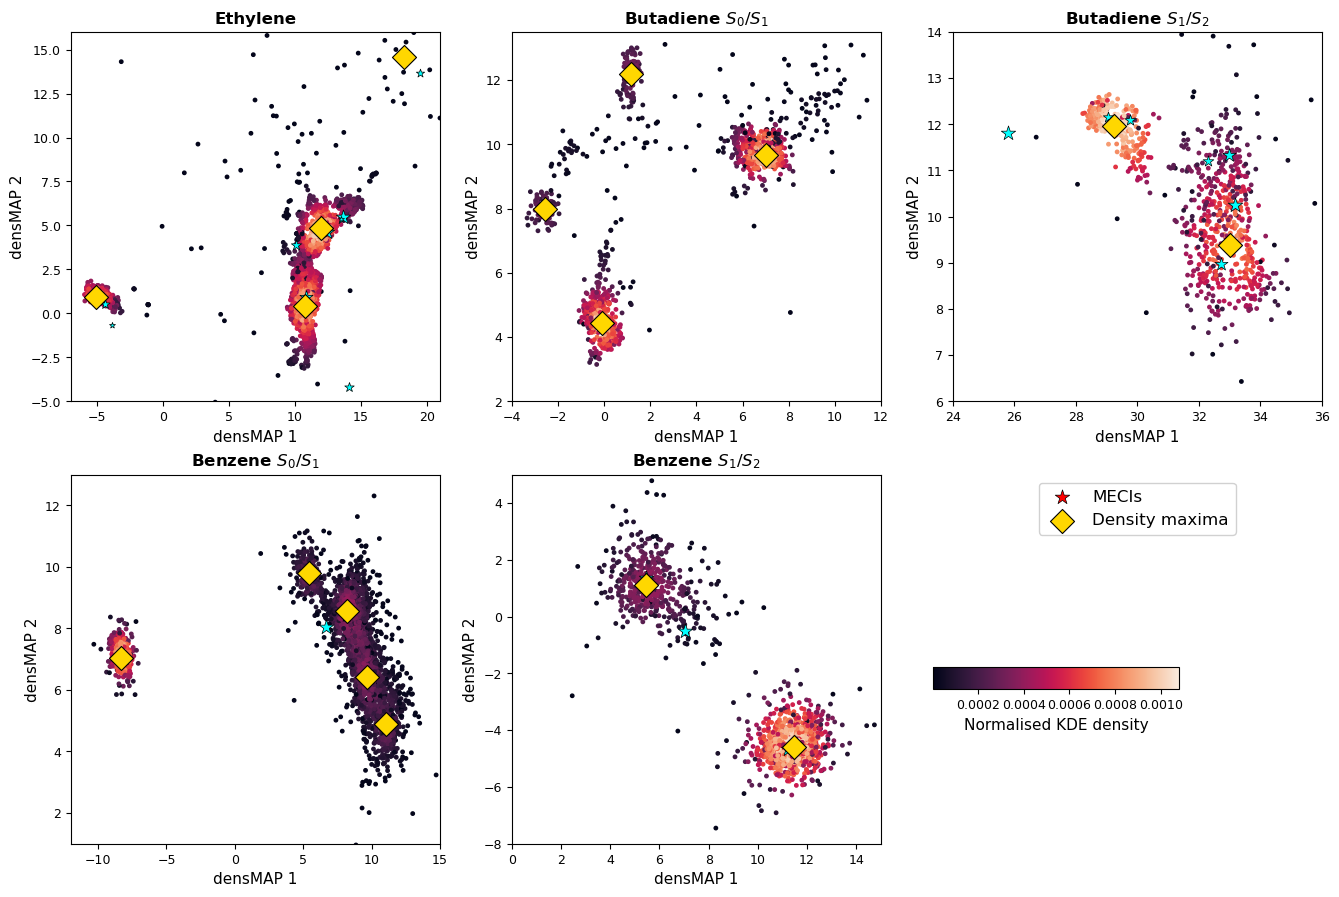

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(FIG_W * 3, FIG_H * 2))
axes_flat  = axes.flatten()
last_sc    = None

for i, name in enumerate(DATASET_ORDER):
    ax = axes_flat[i]
    emb_spawn, emb_meci, spawn_density, zz3d, axes_1d, meci_names = load_dataset(name)
    modes   = find_modes(zz3d, axes_1d, **DATASET_PARAMS[name])
    last_sc = draw_panel(ax, emb_spawn, emb_meci, spawn_density, modes,
                         meci_names, title=TITLES[name], name=name)

# ── Legend panel ─────────────────────────────────────────────────────────────
ax_leg = axes_flat[5]
ax_leg.set_axis_off()

legend_handles = [
    plt.scatter([], [], marker="*", s=MECI_S,  c="red",    edgecolor="k", linewidths=0.5, label="MECIs"),
    plt.scatter([], [], marker="D", s=BASIN_S, c="gold", edgecolor="k", linewidths=0.8, label="Density maxima"),
]
ax_leg.legend(
    handles=legend_handles,
    fontsize=LABEL_SIZE + 1,
    loc="upper center",
    frameon=True,
    framealpha=0.9,
)

# Colorbar inside legend panel
pos    = ax_leg.get_position()
cax    = fig.add_axes([pos.x0 + pos.width * 0.1, pos.y0 + pos.height * 0.35,
                        pos.width * 0.8, pos.height * 0.07])
cbar   = fig.colorbar(last_sc, cax=cax, orientation="horizontal")
cbar.set_label("Normalised KDE density", fontsize=LABEL_SIZE)
cbar.ax.tick_params(labelsize=TICK_SIZE)

fig.tight_layout()
fig.savefig(OUTPUT_FILE, dpi=OUTPUT_DPI, bbox_inches="tight")
print(f"Saved -> {OUTPUT_FILE}")
plt.show()
